# Fraud

The two fraud files give a **fraud probability** for some consumer-days (`consumer_fraud_probability.csv`) and some
merchant-days (`merchant_fraud_probability.csv`). `etl.ipynb` joined both onto the transactions. This notebook decides
what to do with them, and adds four fields to every transaction, saved to `curated/transactions_fraud.parquet`:

| Field | Meaning |
|---|---|
| `fraud_probability` | the chance (0 to 1) that the transaction is fraudulent |
| `fraud_source` | where that number comes from: `fraud file`, `not flagged` or `model` |
| `in_fraud_delta` | matches a supplied consumer-day or merchant-day record, regardless of probability |
| `is_fraud` | `True` when `fraud_probability` is at least 0.5, i.e. the transaction is more likely fraud than not |

1. **What the fraud files contain.** There are two problems with them: they stop on 27 Feb 2022, eight months before the
   transactions do, and they flag far fewer transactions before 28 Aug 2021 than after.
2. **What a flagged day looks like.** It is almost always a day when the consumer spent far more than they usually do.
3. **A model** that learns this from the fraud files and estimates the fraud probability of every transaction after
   27 Feb 2022.
4. **Fraud by merchant category.** This shows where the BNPL firm would lose money, which is the main input to the
   ranking.

In [1]:
from bnpl_validation import valid_raw_transactions
import re
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, StrMethodFormatter
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import average_precision_score, mean_absolute_error, roc_auc_score

Settings and helper functions used throughout this notebook: file paths, key dates, chart colours and formatting.

In [2]:
# Files
TABLES = Path("tables")                # raw data from Canvas
CURATED = Path("curated")              # files the notebooks pass to each other
PLOTS = Path("plots")                  # charts, saved for the presentation
TRANSACTIONS = CURATED / "transactions.parquet"              # from etl.ipynb
TRANSACTIONS_FRAUD = CURATED / "transactions_fraud.parquet"  # from fraud.ipynb

# Key dates
FIRST_DAY = "2021-02-28"        # first day of the transactions
LAST_DAY = "2022-10-26"         # last day of the transactions
SECOND_SNAPSHOT = "2021-08-28"  # first day of the second snapshot: the fraud files flag ~6x more from here
COVERAGE_END = "2022-02-27"     # last day either fraud file covers

# Short names for charts and tables (the full category names are up to 85 characters long)
CATEGORY_LABELS = {
    "computers, computer peripheral equipment, and software": "Computers & software",
    "computer programming, data processing, and integrated systems design services": "IT services",
    "telecom": "Telecom",
    "cable, satellite, and other pay television and radio services": "Pay TV & radio",
    "digital goods: books, movies, music": "Digital goods",
    "furniture, home furnishings and equipment shops, and manufacturers, except appliances": "Furniture",
    "lawn and garden supply outlets, including nurseries": "Lawn & garden",
    "florists supplies, nursery stock, and flowers": "Florists",
    "equipment, tool, furniture, and appliance rental and leasing": "Equipment rental",
    "shoe shops": "Shoe shops",
    "jewelry, watch, clock, and silverware shops": "Jewellery shops",
    "watch, clock, and jewelry repair shops": "Watch & jewellery repair",
    "opticians, optical goods, and eyeglasses": "Opticians",
    "health and beauty spas": "Health & beauty spas",
    "artist supply and craft shops": "Artist supply & craft",
    "art dealers and galleries": "Art dealers",
    "antique shops - sales, repairs, and restoration services": "Antiques",
    "hobby, toy and game shops": "Hobby, toys & games",
    "music shops - musical instruments, pianos, and sheet music": "Music shops",
    "gift, card, novelty, and souvenir shops": "Gifts & souvenirs",
    "books, periodicals, and newspapers": "Books & newspapers",
    "stationery, office supplies and printing and writing paper": "Stationery & office",
    "tent and awning shops": "Tents & awnings",
    "bicycle shops - sales and service": "Bicycle shops",
    "motor vehicle supplies and new parts": "Motor vehicle parts",
}

# Chart colours
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"            # the main colour
ORANGE = "#eb6834"          # what loses money
CONTEXT_GREY = "#b9b8b2"    # everything that isn't the point of the chart


def spark_session():
    """The same Spark settings as etl.ipynb, with the console progress bars and INFO logs turned off."""
    # pyspark 4.2 warns that pandas 3 isn't officially supported yet. Data only moves between pandas and Spark as
    # small aggregates or through parquet files, which works fine.
    warnings.filterwarnings("ignore", message="PySpark does not yet fully support pandas")
    spark = (SparkSession.builder.appName("Project 2")
             .config("spark.sql.repl.eagerEval.enabled", True)
             .config("spark.sql.parquet.cacheMetadata", "true")
             .config("spark.sql.session.timeZone", "Etc/UTC")
             .config("spark.driver.memory", "4g")
             .config("spark.executor.memory", "2g")
             .config("spark.ui.showConsoleProgress", "false")
             .getOrCreate())
    spark.sparkContext.setLogLevel("ERROR")
    return spark


def apply_style():
    """Quiet, consistent chart defaults (the same palette as etl.ipynb). Also stops Jupyter reading the dollar
    signs in tables as maths formulas."""
    pd.set_option("display.html.use_mathjax", False)
    pd.set_option("styler.html.mathjax", False)
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_SECONDARY, "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False, "legend.labelcolor": INK, "font.size": 10,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def money(x, _=None):
    """$950, $12K, $3.4M (also works as an axis tick formatter)."""
    sign, x = ("-" if x < 0 else ""), abs(x)
    if x >= 1e6:
        return f"{sign}${x / 1e6:,.1f}M".replace(".0M", "M")
    if x >= 1e3:
        return f"{sign}${x / 1e3:,.0f}K"
    return f"{sign}${x:,.0f}"


def percent(decimals=0):
    """Axis formatter for a fraction shown as a percentage."""
    return FuncFormatter(lambda x, _: f"{100 * x:.{decimals}f}%")


def show_markdown(text):
    """Display Markdown text. Jupyter reads anything between two dollar signs ("$5 ... $10") as a maths formula, so
    each dollar sign is escaped and wrapped in its own <span> (the markdown cells do the same)."""
    text = re.sub(r"\$(\d(?:[\d,]*\d)?(?:\.\d+)?[KMB]?)", r"<span>\\$\1</span>", text)
    text = re.sub(r"(?<!\\)\$", r"<span>\\$</span>", text)
    display(Markdown(text))


def suptitle(fig, text):
    """A left-aligned title over a figure with several charts."""
    fig.suptitle(text, x=0.01, ha="left", color=INK, fontsize=13)


def save(fig, name):
    """Save a chart to plots/ for the presentation slides."""
    PLOTS.mkdir(exist_ok=True)
    fig.savefig(PLOTS / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
spark = spark_session()
apply_style()

IS_FRAUD_THRESHOLD = 0.5

transactions = spark.read.parquet(str(TRANSACTIONS))
n_transactions = transactions.count()
print(f"{n_transactions:,} transactions from etl.ipynb")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/06 01:32:12 WARN Utils: Your hostname, iphone, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/06 01:32:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/06 01:32:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


13,549,875 transactions from etl.ipynb


## 1. What the fraud files contain

In [4]:
def fraud_file(name, key):
    schema = T.StructType([T.StructField(key, T.LongType()), T.StructField("order_datetime", T.DateType()),
                           T.StructField("fraud_probability", T.DoubleType())])
    return spark.read.csv(str(TABLES / name), header=True, schema=schema, mode="FAILFAST").dropDuplicates()


consumer_fraud = fraud_file("consumer_fraud_probability.csv", "user_id").toPandas()
merchant_fraud = fraud_file("merchant_fraud_probability.csv", "merchant_abn").toPandas()

files = pd.DataFrame({
    name: {
        "rows (one per id and day)": len(frame),
        "distinct ids": frame[key].nunique(),
        "first day": frame["order_datetime"].min(),
        "last day": frame["order_datetime"].max(),
        "lowest probability (%)": round(frame["fraud_probability"].min(), 1),
        "median probability (%)": round(frame["fraud_probability"].median(), 1),
        "highest probability (%)": round(frame["fraud_probability"].max(), 1),
        "transactions it scores": transactions.filter(F.col(column).isNotNull()).count(),
    }
    for name, frame, key, column in [
        ("consumer fraud file", consumer_fraud, "user_id", "consumer_fraud_probability"),
        ("merchant fraud file", merchant_fraud, "merchant_abn", "merchant_fraud_probability"),
    ]
})
display(files)

,consumer fraud file,merchant fraud file
rows (one per id and day),34765,114
distinct ids,20128,61
first day,2021-02-28,2021-03-25
last day,2022-02-27,2022-02-27
lowest probability (%),8.3,18.2
median probability (%),11.7,32.7
highest probability (%),99.2,94.1
transactions it scores,70114,3963


The supplied files contain probability scores, not confirmed fraud outcomes. Their lowest probabilities are
above 8%, and most consumer-day scores are well below 50%.

- An unlisted day is assigned **zero as a modelling proxy within coverage**, not as proof that it is genuine.
  The spec does not establish the false-negative rate of these files.
- `in_fraud_delta` preserves every supplied match. `is_fraud` separately marks probability of at least 50%.
- A $1,000 purchase with a 12% score contributes $120 to expected exposure, not an observed $120 loss.
- Consumer and merchant probabilities are combined under an explicit independence assumption.

The merchant file contains 114 merchant-days from 61 merchants. The weekly chart shows the coverage limits.


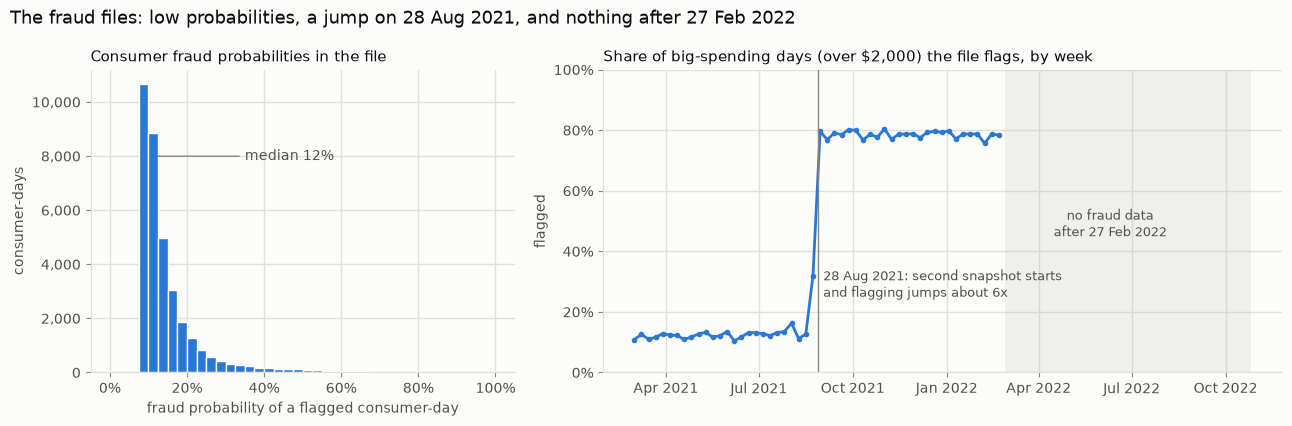

In [5]:
# Share of big-spending consumer-days (over $2,000, about 20x a typical day) that the consumer file flags, by week
user_days_all = (transactions.groupBy("user_id", "order_datetime")
                 .agg(F.sum("dollar_value").alias("day_spend"),
                      F.max("consumer_fraud_probability").alias("consumer_fraud_probability")))
weekly = (user_days_all.filter(F.col("day_spend") > 2000)
          .groupBy(F.date_trunc("week", "order_datetime").alias("week"))
          .agg(F.avg(F.col("consumer_fraud_probability").isNotNull().cast("int")).alias("share_flagged"),
               F.count("*").alias("big_days"))
          .orderBy("week").toPandas())
weekly["week"] = pd.to_datetime(weekly["week"])
# whole weeks inside the fraud files' coverage only (the first week starts before 28 Feb 2021)
weekly = weekly[(weekly["week"] >= FIRST_DAY) & (weekly["week"] + pd.Timedelta(days=6) <= COVERAGE_END)]

fig, (ax_hist, ax_week) = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1, 1.6]})
counts, _, _ = ax_hist.hist(consumer_fraud["fraud_probability"] / 100, bins=np.arange(0, 1.0001, 0.025),
                            color=BLUE, edgecolor="white", linewidth=1)
ax_hist.xaxis.set_major_formatter(percent())
ax_hist.set_title("Consumer fraud probabilities in the file")
ax_hist.set_xlabel("fraud probability of a flagged consumer-day")
ax_hist.set_ylabel("consumer-days")
ax_hist.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax_hist.annotate(f"median {consumer_fraud['fraud_probability'].median():.0f}%",
                 xy=(consumer_fraud["fraud_probability"].median() / 100, 0.75 * counts.max()),
                 xytext=(0.35, 0.75 * counts.max()),
                 color=INK_SECONDARY, va="center", arrowprops=dict(arrowstyle="-", color=MUTED))

ax_week.plot(weekly["week"], weekly["share_flagged"], color=BLUE, marker="o", markersize=3)
ax_week.axvspan(pd.Timestamp(COVERAGE_END), pd.Timestamp(LAST_DAY), color=CONTEXT_GREY, alpha=0.18, linewidth=0)
ax_week.axvline(pd.Timestamp(SECOND_SNAPSHOT), color=MUTED, linewidth=1)
ax_week.text(pd.Timestamp(SECOND_SNAPSHOT) + pd.Timedelta(days=5), 0.25,
             "28 Aug 2021: second snapshot starts\nand flagging jumps about 6x", color=INK_SECONDARY, fontsize=9)
ax_week.text(pd.Timestamp("2022-06-10"), 0.45, "no fraud data\nafter 27 Feb 2022", color=INK_SECONDARY,
             fontsize=9, ha="center")
ax_week.yaxis.set_major_formatter(percent())
ax_week.set_ylim(0, 1)
ax_week.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax_week.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_week.set_title("Share of big-spending days (over $2,000) the file flags, by week")
ax_week.set_ylabel("flagged")
suptitle(fig, "The fraud files: low probabilities, a jump on 28 Aug 2021, and nothing after 27 Feb 2022")
fig.tight_layout()
save(fig, "fraud_files")
plt.show()

- **The files stop on 27 Feb 2022.** The last eight months of transactions (28 Feb to 26 Oct 2022, more than 40% of
  the data) have no fraud information at all. Section 3 builds a model to fill that gap.
- **Flagging jumps on 28 Aug 2021**, the first day of the second transaction snapshot. Before it, about 12% of
  big-spending days are flagged; from that day on, about 78% are. The coincidence with a snapshot boundary suggests a change in the flagging process, rather than proving
  a sudden change in underlying fraud. We treat the earlier period as potentially under-recorded for modelling;
  the files alone do not establish why the change occurred. From here on, only data from 28 Aug 2021 onwards is used
  to learn what fraud looks like and to measure each merchant's fraud rate. That's six months of consistent flagging.

## 2. What a flagged day looks like

Consumer fraud is scored per **consumer-day**, so this section looks at each consumer's total spending on each
day, using the six months of consistent flagging (28 Aug 2021 to 27 Feb 2022).

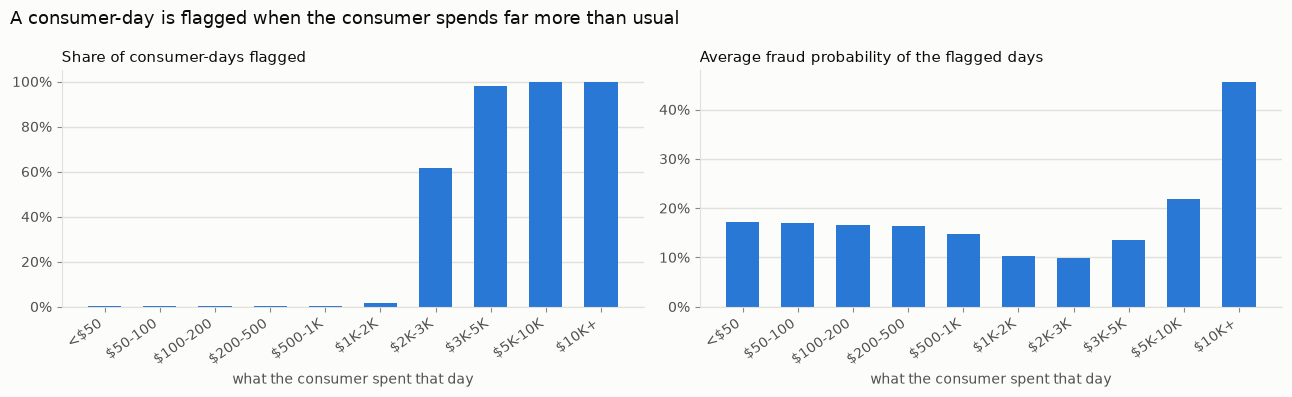

,consumer_days,flagged (%),probability if flagged (%)
day spend,,,
<$50,782546,0.13,17.1
$50-100,498134,0.16,16.9
$100-200,544512,0.15,16.6
$200-500,541188,0.19,16.3
$500-1K,221483,0.26,14.8
$1K-2K,77155,1.81,10.3
$2K-3K,15741,61.50,9.9
$3K-5K,9002,98.22,13.5
$5K-10K,3133,100.00,21.8


In [6]:
SPEND_BUCKETS = [0, 50, 100, 200, 500, 1_000, 2_000, 3_000, 5_000, 10_000, np.inf]
BUCKET_LABELS = ["<$50", "$50-100", "$100-200", "$200-500", "$500-1K", "$1K-2K", "$2K-3K", "$3K-5K", "$5K-10K", "$10K+"]

consistent = user_days_all.filter(F.col("order_datetime").between(SECOND_SNAPSHOT, COVERAGE_END))
bucket = F.lit(len(SPEND_BUCKETS) - 2)
for i in reversed(range(len(SPEND_BUCKETS) - 2)):
    bucket = F.when(F.col("day_spend") < SPEND_BUCKETS[i + 1], i).otherwise(bucket)

by_spend = (consistent.withColumn("bucket", bucket)
            .groupBy("bucket")
            .agg(F.count("*").alias("consumer_days"),
                 F.avg(F.col("consumer_fraud_probability").isNotNull().cast("int")).alias("share_flagged"),
                 (F.avg("consumer_fraud_probability") / 100).alias("probability_if_flagged"))
            .orderBy("bucket").toPandas())
by_spend["day spend"] = [BUCKET_LABELS[i] for i in by_spend["bucket"]]
by_spend = by_spend.set_index("day spend").drop(columns="bucket")

typical_day = consistent.approxQuantile("day_spend", [0.5], 0.001)[0]
flagged_day = consistent.filter(F.col("consumer_fraud_probability").isNotNull()).approxQuantile("day_spend", [0.5], 0.001)[0]

fig, (ax_share, ax_prob) = plt.subplots(1, 2, figsize=(13, 4.0), sharex=True)
x = np.arange(len(by_spend))
ax_share.bar(x, by_spend["share_flagged"], width=0.6, color=BLUE)
ax_share.set_title("Share of consumer-days flagged")
ax_share.yaxis.set_major_formatter(percent())
ax_prob.bar(x, by_spend["probability_if_flagged"], width=0.6, color=BLUE)
ax_prob.set_title("Average fraud probability of the flagged days")
ax_prob.yaxis.set_major_formatter(percent())
for ax in (ax_share, ax_prob):
    ax.set_xticks(x, by_spend.index, rotation=35, ha="right")
    ax.set_xlabel("what the consumer spent that day")
    ax.grid(axis="x", visible=False)
suptitle(fig, "A consumer-day is flagged when the consumer spends far more than usual")
fig.tight_layout()
save(fig, "fraud_by_day_spend")
plt.show()

display(by_spend.assign(share_flagged=lambda d: (100 * d["share_flagged"]).round(2),
                        probability_if_flagged=lambda d: (100 * d["probability_if_flagged"]).round(1))
        .rename(columns={"share_flagged": "flagged (%)", "probability_if_flagged": "probability if flagged (%)"}))

The pattern is very strong:

- **Below <span>\$1,000</span> a day, almost nothing is flagged** (about 0.2% of days). A typical consumer-day is about
  **<span>\$110</span>**, and flagged days have a median spend of about **<span>\$2,900</span>**.
- **From <span>\$2,000</span> a day most days are flagged** (62% of <span>\$2K</span>-3K days, and practically every day above <span>\$3,000</span>), and the
  bigger the day, the higher the probability: a flagged day over <span>\$10,000</span> averages a **46%** chance of fraud.
- Flagged days *under* <span>\$1,000</span> are rare, but their probability (about 16%) is higher than that of <span>\$1K</span>-3K days.
  So spend isn't the only thing the fraud files look at, which is why the model below uses more than the day's total.

This is the "high volume transactions for a consumer who rarely purchases" pattern from the spec. Every consumer
here shops on most days, so what stands out is how much they spend on a given day compared with their usual day.

## 3. A model for the transactions the fraud files don't cover

A fraud probability is now estimated for each consumer-day from 28 Feb 2022, using only what the BNPL firm would
know by the end of that day:

| Feature | Meaning |
|---|---|
| `log_day_spend` | how much the consumer spent that day, in dollars (log scale) |
| `log_largest_purchase` | the largest single purchase that day, in dollars (log scale) |
| `log_spend_vs_usual` | that day's spend divided by the consumer's usual (median) day (log scale) |
| `purchases` | number of purchases that day |
| `merchants` | number of different merchants that day |

The fraud file answers two questions, so the model has two parts:
1. **Is the day flagged?** A classifier gives the chance that the day is flagged.
2. **If it is flagged, how likely is it to be fraud?** A regression, trained on flagged days only, gives the
   probability.

The expected fraud probability is the product of the two. Both parts are gradient-boosted decision trees
(`HistGradientBoosting` in scikit-learn), which handle the sharp jump around <span>\$2,000</span> without manual feature tuning.
The model is trained on 28 Aug to 31 Dec 2021 and tested on the two months it never saw (Jan and Feb 2022).
It's compared against a simple **baseline**: the training-period average for that day's spend bucket.
For this test, usual spending is fitted only through 31 Dec 2021. Features use valid raw purchases and retain
unusual amounts, so full-period outlier cut-offs cannot leak into this test. The model learns the supplied
flagging/probability process; this does not validate real-world fraud outcomes.

In [7]:
FEATURES = ["log_day_spend", "log_largest_purchase", "log_spend_vs_usual", "purchases", "merchants"]
USER_DAYS_FILE = CURATED / "fraud_user_days.parquet"

# Retain valid unusual purchases; full-period ETL fences must not affect validation.
raw_for_fraud = (valid_raw_transactions(spark)
                 .join(fraud_file("consumer_fraud_probability.csv", "user_id")
                       .withColumnRenamed("fraud_probability", "consumer_fraud_probability"),
                       ["user_id", "order_datetime"], "left"))
user_days = (raw_for_fraud.filter(F.col("order_datetime") >= SECOND_SNAPSHOT)
             .groupBy("user_id", "order_datetime")
             .agg(F.sum("dollar_value").alias("day_spend"),
                  F.max("dollar_value").alias("largest_purchase"),
                  F.count("*").alias("purchases"),
                  F.countDistinct("merchant_abn").alias("merchants"),
                  F.max("consumer_fraud_probability").alias("consumer_fraud_probability")))
# Six-month baseline for the FINAL model predicting dates after 27 Feb.
# The earlier validation split receives its own training-only baseline below.
usual = (user_days.filter(F.col("order_datetime") <= COVERAGE_END)
         .groupBy("user_id").agg(F.percentile("day_spend", 0.5).alias("usual_day_spend")))
(user_days.join(usual, "user_id", "left")
 .select("user_id", "order_datetime", "day_spend", "consumer_fraud_probability", "usual_day_spend",
         F.log10("day_spend").cast("float").alias("log_day_spend"),
         F.log10("largest_purchase").cast("float").alias("log_largest_purchase"),
         F.log10(F.col("day_spend") / F.col("usual_day_spend")).cast("float").alias("log_spend_vs_usual"),
         F.col("purchases").cast("int"), F.col("merchants").cast("int"))
 .write.mode("overwrite").parquet(str(USER_DAYS_FILE)))
assert spark.read.parquet(str(USER_DAYS_FILE)).filter(F.col("usual_day_spend").isNull()).count() == 0, \
    "every consumer shops in the six labelled months, so everyone has a usual day"


def load_days(first, last):
    """Consumer-days between two dates (inclusive). Reading only the dates and columns needed keeps memory low."""
    days = pd.read_parquet(USER_DAYS_FILE, columns=["user_id", "order_datetime", "day_spend",
                                                    "consumer_fraud_probability", *FEATURES],
                           filters=[("order_datetime", ">=", pd.Timestamp(first).date()),
                                    ("order_datetime", "<=", pd.Timestamp(last).date())])
    days["flagged"] = days["consumer_fraud_probability"].notna()
    days["probability"] = days["consumer_fraud_probability"].fillna(0) / 100
    return days


train = load_days(SECOND_SNAPSHOT, "2021-12-31")
test = load_days("2022-01-01", COVERAGE_END)
usual_training = train.groupby("user_id")["day_spend"].median()
for frame in [train, test]:
    baseline_spend = frame["user_id"].map(usual_training)
    assert baseline_spend.notna().all(), "a validation user has no training history"
    frame["log_spend_vs_usual"] = np.log10(frame["day_spend"] / baseline_spend).astype("float32")
print(f"consumer-days: {len(train):,} to train on (28 Aug - 31 Dec 2021), {len(test):,} to test on (Jan - Feb 2022)")


def fit_model(data):
    classifier = HistGradientBoostingClassifier(max_iter=300, min_samples_leaf=200, random_state=0)
    classifier.fit(data[FEATURES], data["flagged"])
    flagged = data[data["flagged"]]
    regressor = HistGradientBoostingRegressor(max_iter=300, min_samples_leaf=50, random_state=0)
    regressor.fit(flagged[FEATURES], flagged["probability"])
    return classifier, regressor


def predict(model, data):
    classifier, regressor = model
    chance_flagged = classifier.predict_proba(data[FEATURES])[:, 1]
    probability_if_flagged = regressor.predict(data[FEATURES]).clip(0, 1)
    return chance_flagged, probability_if_flagged


def spend_bucket(spend):
    return pd.cut(spend, SPEND_BUCKETS, right=False, labels=BUCKET_LABELS)


model = fit_model(train)
chance_flagged, probability_if_flagged = predict(model, test)
predicted = chance_flagged * probability_if_flagged

lookup = train.groupby(spend_bucket(train["day_spend"]), observed=False).agg(
    chance_flagged=("flagged", "mean"), expected=("probability", "mean"))
test_buckets = spend_bucket(test["day_spend"])
baseline_chance = test_buckets.map(lookup["chance_flagged"]).astype(float).to_numpy()
baseline = test_buckets.map(lookup["expected"]).astype(float).to_numpy()
baseline_if_flagged = test_buckets.map(lookup["expected"] / lookup["chance_flagged"]).astype(float).to_numpy()

is_flagged = test["flagged"].to_numpy()
actual_fraud_dollars = (test["probability"] * test["day_spend"]).sum()
scores = pd.DataFrame({
    name: {
        "finds flagged days: ROC AUC (1 = perfect, 0.5 = guessing)": roc_auc_score(is_flagged, chance),
        "finds flagged days: average precision": average_precision_score(is_flagged, chance),
        "probability of flagged days: mean absolute error (points)": 100 * mean_absolute_error(
            test.loc[is_flagged, "probability"], if_flagged[is_flagged]),
        "expected fraud $ predicted / supplied scores": (expected * test["day_spend"]).sum() / actual_fraud_dollars,
    }
    for name, chance, if_flagged, expected in [
        ("baseline (spend bucket average)", baseline_chance, baseline_if_flagged, baseline),
        ("model", chance_flagged, probability_if_flagged, predicted),
    ]
})
display(scores.round(3))
scores.to_csv(CURATED / "fraud_model_validation.csv")

consumer-days: 1,978,411 to train on (28 Aug - 31 Dec 2021), 722,993 to test on (Jan - Feb 2022)


,baseline (spend bucket average),model
"finds flagged days: ROC AUC (1 = perfect, 0.5 = guessing)",0.950,0.950
finds flagged days: average precision,0.786,0.856
probability of flagged days: mean absolute error (points),2.907,2.095
expected fraud $ predicted / supplied scores,0.934,1.003


The table evaluates discrimination of **supplied flags**, error against **supplied probabilities**, and predicted
exposure against the exposure implied by those scores. Lower probability error and an exposure ratio near one
are desirable. AUC alone does not establish calibration or real loss accuracy.

This comparison uses a chronological January-February holdout and training-only spending baselines.


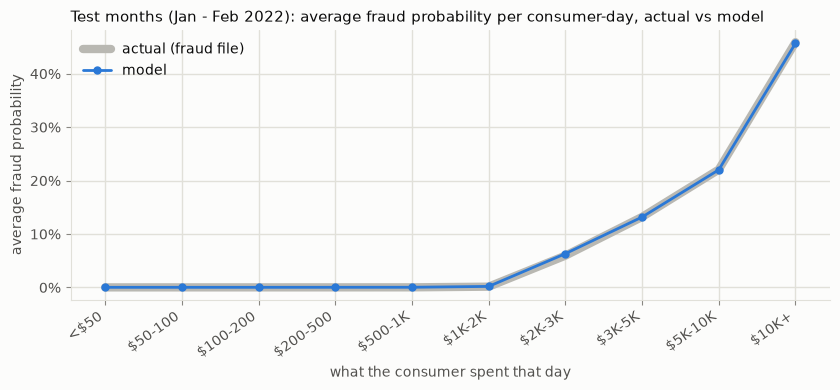

In [8]:
check = (pd.DataFrame({"actual": test["probability"].to_numpy(), "model": predicted})
         .groupby(test_buckets.to_numpy(), observed=False).mean()
         .reindex(BUCKET_LABELS))  # spend buckets in order, smallest first

fig, ax = plt.subplots(figsize=(8.5, 4.0))
x = np.arange(len(check))
ax.plot(x, check["actual"], color=CONTEXT_GREY, linewidth=6, solid_capstyle="round", label="actual (fraud file)")
ax.plot(x, check["model"], color=BLUE, marker="o", markersize=5, label="model")
ax.set_xticks(x, check.index, rotation=35, ha="right")
ax.yaxis.set_major_formatter(percent())
ax.set_xlabel("what the consumer spent that day")
ax.set_ylabel("average fraud probability")
ax.legend(loc="upper left")
ax.set_title("Test months (Jan - Feb 2022): average fraud probability per consumer-day, actual vs model")
fig.tight_layout()
save(fig, "fraud_model_check")
plt.show()

The final model is refitted on all six labelled months (28 Aug 2021 to 27 Feb 2022), with usual spending
recomputed from those six months. All precede the dates being estimated.

The merchant file has only 114 merchant-days, so the later model estimates consumer risk only. That missing
component remains a limitation, particularly when interpreting unusual large losses.


In [9]:
full_training = pd.concat([train, test], ignore_index=True)
usual_full = full_training.groupby("user_id")["day_spend"].median()
full_training["log_spend_vs_usual"] = np.log10(
    full_training["day_spend"] / full_training["user_id"].map(usual_full)).astype("float32")
final_model = fit_model(full_training)
del full_training
del train  # free memory before predicting

# predict month by month so only one month of consumer-days is in memory at a time
predictions = []
for first in pd.date_range("2022-02-28", LAST_DAY, freq="30D"):
    chunk = load_days(first, min(first + pd.Timedelta(days=29), pd.Timestamp(LAST_DAY)))
    chance, if_flagged = predict(final_model, chunk)
    predictions.append(pd.DataFrame({"user_id": chunk["user_id"], "order_datetime": chunk["order_datetime"],
                                     "model_fraud_probability": chance * if_flagged}))
predictions = pd.concat(predictions, ignore_index=True)
assert not predictions.duplicated(["user_id", "order_datetime"]).any()

PREDICTIONS_FILE = CURATED / "fraud_predictions.parquet"
predictions.to_parquet(PREDICTIONS_FILE, index=False)
print(f"{len(predictions):,} consumer-days predicted (28 Feb - 26 Oct 2022)")
display(predictions["model_fraud_probability"].describe(percentiles=[0.5, 0.9, 0.99, 0.999]).to_frame().T.round(4))

3,657,001 consumer-days predicted (28 Feb - 26 Oct 2022)


,count,mean,std,min,50%,90%,99%,99.9%,max
model_fraud_probability,3657001.0,0.0016,0.0156,0.0001,0.0002,0.0003,0.0362,0.2113,0.7251


## 4. One fraud probability for every transaction

- **Up to 27 Feb 2022** (the files' coverage): a transaction gets the probability from the consumer file, the
  merchant file, or both. A consumer and a merchant being fraudulent are treated as independent, so the transaction
  is genuine only if neither is: `1 - (1 - consumer) x (1 - merchant)`. A transaction in neither file gets the assumed zero proxy
  (`not flagged`), not a verified genuine label.
- **From 28 Feb 2022**: the model's estimate for that consumer-day (`model`).
- `in_fraud_delta` preserves every supplied match, even below the 50% threshold.
- `is_fraud` is `True` when the probability is at least 0.5. It's kept to label and count likely fraud, but no
  transaction is deleted: everything downstream uses `fraud_probability` as an expected value, so a transaction with
  a 30% probability counts as 30% fraud.

In [10]:
model_predictions = spark.read.parquet(str(PREDICTIONS_FILE))

consumer_p = F.coalesce(F.col("consumer_fraud_probability") / 100, F.lit(0.0))
merchant_p = F.coalesce(F.col("merchant_fraud_probability") / 100, F.lit(0.0))
in_file = F.col("consumer_fraud_probability").isNotNull() | F.col("merchant_fraud_probability").isNotNull()
covered = F.col("order_datetime") <= COVERAGE_END

transactions_fraud = (transactions
                      .join(model_predictions, on=["user_id", "order_datetime"], how="left")
                      .withColumn("fraud_probability",
                                  F.when(covered, 1 - (1 - consumer_p) * (1 - merchant_p))
                                  .otherwise(F.col("model_fraud_probability")))
                      .withColumn("fraud_source", F.when(covered & in_file, "fraud file")
                                  .when(covered, "not flagged").otherwise("model"))
                      .withColumn("in_fraud_delta", covered & in_file)
                      .withColumn("is_fraud", F.col("fraud_probability") >= IS_FRAUD_THRESHOLD)
                      .drop("model_fraud_probability"))
transactions_fraud.write.mode("overwrite").parquet(str(TRANSACTIONS_FRAUD))

saved = spark.read.parquet(str(TRANSACTIONS_FRAUD))
n_saved = saved.count()
assert n_saved == n_transactions, "the fraud join changed the number of transactions"
assert saved.select("order_id").distinct().count() == n_saved, "order_id is not unique"
assert saved.filter(F.col("fraud_probability").isNull()).count() == 0, "a transaction has no fraud probability"
assert saved.filter(~F.col("fraud_probability").between(0, 1) | F.isnan("fraud_probability")).count() == 0

by_source = (saved.groupBy("fraud_source")
             .agg(F.count("*").alias("transactions"),
                  F.avg("fraud_probability").alias("mean_probability"),
                  F.sum(F.col("fraud_probability") * F.col("dollar_value")).alias("expected_fraud_dollars"),
                  F.sum(F.col("is_fraud").cast("int")).alias("is_fraud"))
             .toPandas().set_index("fraud_source").loc[["fraud file", "not flagged", "model"]])
by_source.insert(1, "share_of_transactions_pct", (100 * by_source["transactions"] / n_saved).round(2))
display(by_source.round({"mean_probability": 4, "expected_fraud_dollars": 0}))

,transactions,share_of_transactions_pct,mean_probability,expected_fraud_dollars,is_fraud
fraud_source,,,,,
fraud file,73726,0.54,0.1542,27348387.0,1166
not flagged,7706811,56.88,0.0000,0.0,0
model,5769338,42.58,0.0020,29005734.0,950


## 5. Fraud by merchant category

Fraud matters far more to a BNPL firm than its size suggests. On a genuine purchase the firm earns its take rate
(0.1% to 7% of the sale). On a fraudulent one it has already paid the merchant and is never repaid, so it loses the
whole amount. For every dollar of sales:

$$\text{expected profit} = \text{take rate} \times (1 - p) - p \times (1 - \text{take rate}) = \text{take rate} - p$$

where $p$ is the fraud probability. A sale only makes money in expectation when **its take rate is higher than its
fraud probability**. The chart compares the two for each merchant category, using the period with consistent
flagging (28 Aug 2021 onwards: fraud-file probabilities, then the model's).

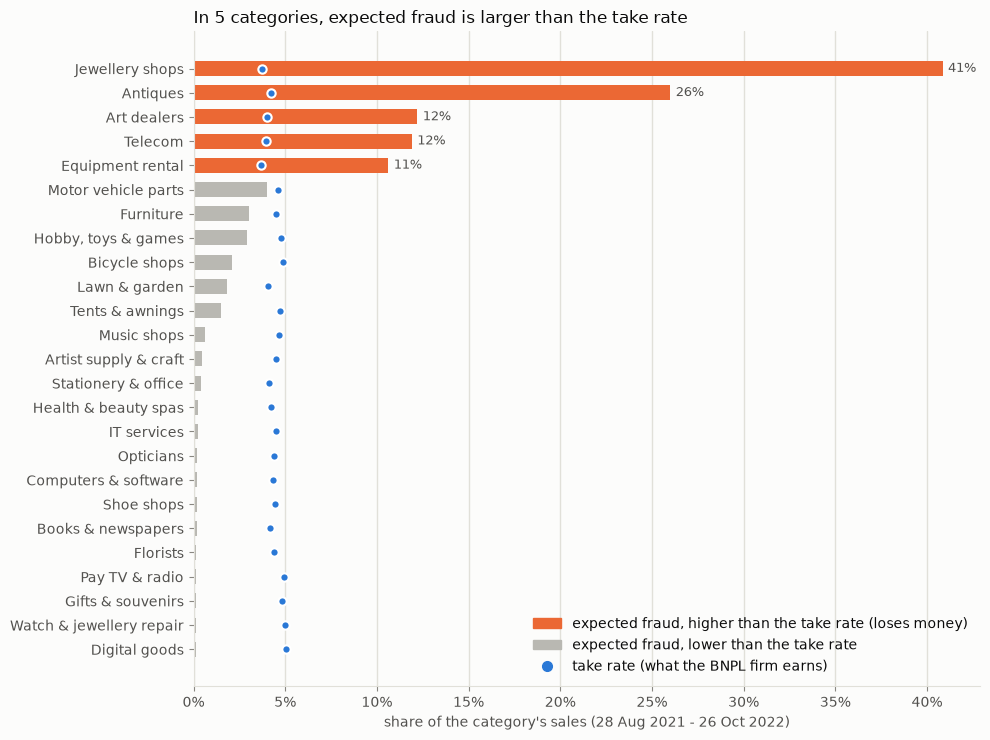

,median order ($),take rate (%),expected fraud (%)
label,,,
Jewellery shops,7704.0,3.74,40.85
Antiques,125.0,4.23,26.00
Art dealers,1509.0,4.03,12.21
Telecom,1190.0,3.94,11.90
Equipment rental,585.0,3.66,10.62
Motor vehicle parts,234.0,4.62,4.02
Furniture,133.0,4.52,3.02
"Hobby, toys & games",86.0,4.75,2.93
Bicycle shops,110.0,4.89,2.11


In [11]:
category_fraud = (saved.filter(F.col("order_datetime") >= SECOND_SNAPSHOT)
                  .groupBy("category")
                  .agg(F.sum("dollar_value").alias("sales"),
                       F.sum(F.col("dollar_value") * F.col("take_rate") / 100).alias("bnpl_revenue"),
                       F.sum(F.col("dollar_value") * F.col("fraud_probability")).alias("expected_fraud"),
                       F.percentile_approx("dollar_value", 0.5).alias("median_order"))
                  .toPandas())
category_fraud["take_rate"] = category_fraud["bnpl_revenue"] / category_fraud["sales"]
category_fraud["fraud_rate"] = category_fraud["expected_fraud"] / category_fraud["sales"]
category_fraud["label"] = category_fraud["category"].map(CATEGORY_LABELS)
category_fraud = category_fraud.sort_values("fraud_rate").reset_index(drop=True)
loses_money = category_fraud["fraud_rate"] > category_fraud["take_rate"]

fig, ax = plt.subplots(figsize=(10, 7.5))
y = np.arange(len(category_fraud))
ax.barh(y, category_fraud["fraud_rate"], height=0.62, color=np.where(loses_money, ORANGE, CONTEXT_GREY))
ax.scatter(category_fraud["take_rate"], y, s=36, color=BLUE, zorder=3, edgecolor="white", linewidth=1.5)
ax.set_yticks(y, category_fraud["label"])
ax.xaxis.set_major_formatter(percent())
ax.set_xlabel("share of the category's sales (28 Aug 2021 - 26 Oct 2022)")
ax.grid(axis="y", visible=False)
for i in np.flatnonzero(loses_money):
    ax.text(category_fraud.loc[i, "fraud_rate"] + 0.003, i, f"{category_fraud.loc[i, 'fraud_rate']:.0%}",
            va="center", color=INK_SECONDARY, fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, color=ORANGE), plt.Rectangle((0, 0), 1, 1, color=CONTEXT_GREY),
           plt.Line2D([], [], marker="o", linestyle="", color=BLUE, markersize=7)]
ax.legend(handles, ["expected fraud, higher than the take rate (loses money)", "expected fraud, lower than the take rate",
                    "take rate (what the BNPL firm earns)"], loc="lower right")
ax.set_title(f"In {loses_money.sum()} categories, expected fraud is larger than the take rate", fontsize=12)
fig.tight_layout()
save(fig, "fraud_vs_take_rate_by_category")
plt.show()

display(category_fraud.set_index("label")[["median_order", "take_rate", "fraud_rate"]]
        .assign(take_rate=lambda d: (100 * d["take_rate"]).round(2), fraud_rate=lambda d: (100 * d["fraud_rate"]).round(2),
                median_order=lambda d: d["median_order"].round(0))
        .rename(columns={"median_order": "median order ($)", "take_rate": "take rate (%)",
                         "fraud_rate": "expected fraud (%)"})
        .sort_values("expected fraud (%)", ascending=False))

**Fraud follows the size of the purchase.** The categories that lose money are the ones that sell big-ticket items:
jewellery shops (median order about <span>\$7,700</span>), art dealers (about <span>\$1,500</span>) and telecom (about <span>\$1,200</span>), plus antiques
and equipment rental, whose typical order is small but which also sell items worth thousands. A single big order
makes the consumer's day a "big-spending day", which is exactly what the fraud files flag. Everyday categories such
as digital goods, gifts and florists have expected fraud well under 1% of sales, far below their take rates.

This separates merchants more sharply than anything else in the data, so the ranking (`ranking.ipynb`) subtracts
each merchant's expected fraud losses from its revenue.

In [12]:
revenue_since = category_fraud["bnpl_revenue"].sum()
fraud_since = category_fraud["expected_fraud"].sum()
n_is_fraud = int(by_source["is_fraud"].sum())
test_auc = scores.loc["finds flagged days: ROC AUC (1 = perfect, 0.5 = guessing)", "model"]
test_ratio = scores.loc["expected fraud $ predicted / supplied scores", "model"]
show_markdown(f"""
### Summary

- **What was done with the fraud files.** Nothing was deleted. Every transaction now has a `fraud_probability`: from
  the fraud files up to 27 Feb 2022 (0 if not flagged), and from a model after that. `is_fraud` marks the
  **{n_is_fraud:,}** transactions whose probability is at least 0.5.
- **What fraud looks like.** Flagged consumer-days have a median spend of **${flagged_day:,.0f}**, against
  **${typical_day:,.0f}** for a typical day. Days under $1,000 are almost never flagged.
- **Data issues.** The files stop on 27 Feb 2022, and they flag about 6x fewer big-spending days before
  28 Aug 2021 (the second snapshot) than after. Fraud is therefore learned and measured from 28 Aug 2021 onwards only.
- **The model** (two gradient-boosted tree models: is the day flagged, and if so how likely is it to be fraud) scores a
  ROC AUC of **{test_auc:.2f}** on the chronological holdout. It predicts **{test_ratio:.2f}x** the exposure implied by supplied scores.
- **Why it matters.** Since 28 Aug 2021, expected fraud comes to **{money(fraud_since)}**, against
  **{money(revenue_since)}** of BNPL revenue (take rate x sales). A fraudulent sale costs the firm the whole amount,
  so a sale only pays when its take rate is above its fraud probability. In **{loses_money.sum()} big-ticket
  categories** it isn't.

**Output:** `{TRANSACTIONS_FRAUD}`, {n_saved:,} rows: the ETL columns plus `fraud_probability`, `fraud_source`, `in_fraud_delta` and `is_fraud`.
""")


### Summary

- **What was done with the fraud files.** Nothing was deleted. Every transaction now has a `fraud_probability`: from
  the fraud files up to 27 Feb 2022 (0 if not flagged), and from a model after that. `is_fraud` marks the
  **2,116** transactions whose probability is at least 0.5.
- **What fraud looks like.** Flagged consumer-days have a median spend of **<span>\$2,874</span>**, against
  **<span>\$109</span>** for a typical day. Days under <span>\$1,000</span> are almost never flagged.
- **Data issues.** The files stop on 27 Feb 2022, and they flag about 6x fewer big-spending days before
  28 Aug 2021 (the second snapshot) than after. Fraud is therefore learned and measured from 28 Aug 2021 onwards only.
- **The model** (two gradient-boosted tree models: is the day flagged, and if so how likely is it to be fraud) scores a
  ROC AUC of **0.95** on the chronological holdout. It predicts **1.00x** the exposure implied by supplied scores.
- **Why it matters.** Since 28 Aug 2021, expected fraud comes to **<span>\$51.8M</span>**, against
  **<span>\$70.2M</span>** of BNPL revenue (take rate x sales). A fraudulent sale costs the firm the whole amount,
  so a sale only pays when its take rate is above its fraud probability. In **5 big-ticket
  categories** it isn't.

**Output:** `curated/transactions_fraud.parquet`, 13,549,875 rows: the ETL columns plus `fraud_probability`, `fraud_source`, `in_fraud_delta` and `is_fraud`.
